# Multiple-beam Interference in a Thin Film

## 1. Fabry-Pérot Resonator Model

We consider a monochromatic plane electromagnetic wave of wavelength $\lambda$ incident on a thin dielectric film of refractive index $n_2$ and thickness d. 
The film is surrounded by two semi-infinite media with refractive indices $n_1$ (incident medium) and $n_3$ (substrate).

At each interface, partial reflection and transmission occurs according to Fresnel's equations. The wave undergoes multiple reflections inside the film, giving rise to multiple-beam interference.

The observable reflected intensity results from the coherent superposition of all reflected waves.

## 2. Monochromatic Plane Wave

We assume harmonic time dependence:

$E(r,t) = Re\{E(r)e^{-iwt}\}$

This harmonic time dependence allows the problem to be treated in the frequency domain. The phase accumulated during propagation determines the interference behavior.

## 3. Phase Accumulation Inside the Film

For a wave propagating inside the film, the accumulates a phase is:

$\delta = \dfrac{2\hspace{0.1cm}n_2 \hspace{0.1cm}d \hspace{0.1cm}\cos(\phi_2)}{\lambda}$

where:

- $\lambda$ is the wavelength in the vacuum
- $n_2$ in the refractive index of the film
- $\phi_2$ is the angle inside the film
- The factor $2$ accounts for round-trip propagation

For normal incidence ($\phi_2= 0$)

$\delta = \dfrac{4\hspace{0.05cm}\pi\hspace{0.05cm} n_2\hspace{0.05cm} d}{\lambda}$

This phase difference determines constructive and destructive conditions.

## 4. Interference Condition

Constructive interference occurs when:

$\delta = 2m \pi$

$ 2n_2 d = m\lambda $

where m is an integer.

Destructive interference ocurs when:

$\delta = (2m +1) \pi$

## 5. Total Reflection Coefficient

The total reflected amplitude is obtained by assuming the infinite series of multiple reflections inside the film. The result can be written as:

$r_{total} = \dfrac{r_{12}+r_{23}\hspace{0.05cm}e^{i\delta}}{1 + r_{12}\hspace{0.05cm}r_{23}\hspace{0.05cm}e^{i\delta}}$

where :

- $r_{12}$ is the Fresnel's reflection coefficient at the first interface
- $r_{23}$ is the Fresnel's reflection coefficient at the second interface ç
- $\delta$ is the accumulated phase

The observable reflectence is:

$ R = |r_{total}|^2$

## 6. Physical Interpretation

The thin film behaves as an optical resonator. For specific wavelengths, constructive interference enhances reflection, producing resonance peaks. For others wavelengths, destructive interference reduces reflection.

This principle is fundamental in:

- Anti-reflection coatings
- Fabry-Pérot Interferometers
- Optical Filters
- Laser cavities
- Optical Sensors

## 7. Energy Conservation

In lossless dielectric media, the total energy must be conserved. Therefore the reflectance $R$ and trasmittance $T$ satisfy:

$  T = 1 - R$

Any deviation from unity would indicate numerical or modeling errors.

## 8. Transmittance of a Thin Film

In addition to reflectance, the transmitted field results from the coherent superposition of all internally transmitted waves.

The total transmission coefficent can be written as:

$ t_{total} = \dfrac{t_{12}\hspace{0.05cm}t_{23}\hspace{0.05cm}e^{i\delta/2}}{1 + r_{12}\hspace{0.05cm}r_{23}\hspace{0.05cm}e^{i\delta}} $

The observable transmittance is:

$ T = |t_{total}|^2$

For lossless dielectric media energy conservation requires:

$ T + R = 1$

Verifyng this relation numerically provides a strong consistency check for the physical and computational model.

## 9. Free Spectral Range (FRS)

The free spectral range represents the spacing between adjacent resonance peaks in the reflectance spectrum.

For normal incidence, it can be approximated as:

$\Delta\lambda = \dfrac{\lambda^2}{2\hspace{0.05cm}n_2\hspace{0.05cm}d} $

This shows that increasing thickness reduces the spectral separation.

The FRS ia a fundamental parameter in Fabry-Pérot cavities and determines their spectral selectivity.

## 10. High Reflectivity and Finesse

When the interface reflectivity increases, the thin film behaves more strongly as an optical cavity.

First we define the **Coefficient of Finess**, which dictates the contrast of the interference fringes:
$ \mathcal{F}=\dfrac{4R}{(1-R)^2} $

However, the true **Finesse** of the cavity, which represents the ratio between  the Free Spectral Range (FSR) and the Full Width at Half Maximum (FWHM) of the resonance peaks, is defined as:
$ \mathscr{F}=\dfrac{\pi \sqrt{R}}{1-R} $

Higher reflectivity leads to larger finesse values, meaning the cavity can resolve wavelengths with much greater precision (narrower peaks.

In the limit of high reflectivity, the system approach the behavior of an ideal Fabry-Pérot resonator.

## Physical Parameters

The dielectric media selected for the first and third media are air and glass, respectively. The wavelength range corresponds to the visible spectrum, and the thickness of the thin film is of a similar order of magnitude to the wavelength ($500$ $nm$).

In [15]:
import numpy as np
import matplotlib.pyplot as plt

### Refractive indidces

n1 = 1.0     # air
n2 = 1.5     # glass
n3 = 1.0     # air (substrate)


d = 500e-9   # Thin film thickness 500nm

# Wavelength range (visible spectrum)
lambda_ = np.linspace(400e-9, 800e-9, 2000)

We model the Fresnel coefficients at normal incidence, the accumulated phase, total reflection coefficient, and reflectance.

In [16]:
def fresnel_r(n_a, n_b):
    return (n_a - n_b) / (n_a + n_b)

r12 = fresnel_r(n1, n2)  # Reflection coefficient of the first interface
r23 = fresnel_r(n2, n3)  # Reflection coefficient of the first interface

delta = (4 * np.pi * n2 * d) / lambda_     #phase acumulated

# Total reflection coefficient
r_total = (r12 + r23 * np.exp(1j * delta)) / (1 + r12 * r23 * np.exp(1j * delta))

R = np.abs(r_total)**2    # Reflectance

T = 1 - R    # Transmittance
print("Maximum deviation from energy conservation:", np.max(np.abs(R + T -1)))

Maximum deviation from energy conservation: 0.0


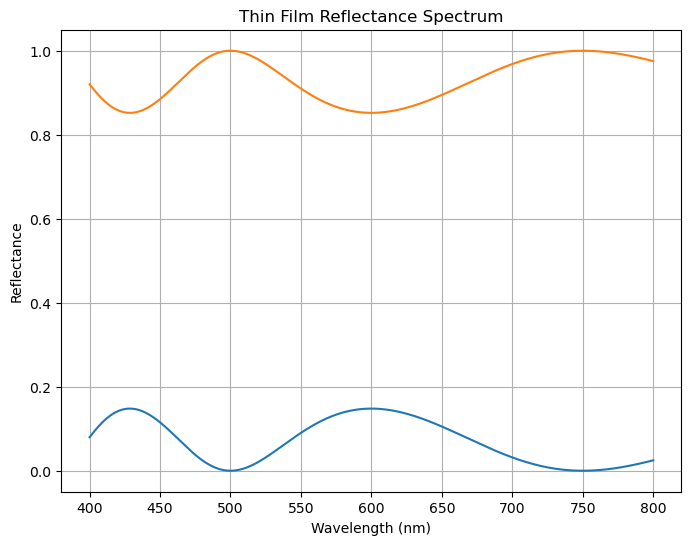

In [21]:
import os

folder_path = "../figures/week 3"
os.makedirs(folder_path, exist_ok=True)

plt.figure(figsize=(8,6))
plt.plot(lambda_ * 1e9, R, label="Reflectance (R)")
plt.plot(lambda_ * 1e9, T, label="Transmittance (T)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Thin Film Reflectance Spectrum")
plt.grid()
plt.savefig(f"{folder_path}/Thin Film Reflectance Spectrum.png", dpi=300)
plt.show()

The periodic oscillations in the reflectance spectrum correspond to constructive and destructive interferences inside the film. The peak positions satisfy the resonance condition $2 n_2 d = m\lambda$.

We model its behavior with regard to transmission and verification of energy conservation. With regard to transmittance, we observe a clear conservation of the energy factor by maintaining the unit.

In [ ]:
lambda0 = 600e-9  # central wavelength
FSR = lambda0**2 / (2 * n2 * d)

print("Approximate FSR(nm):", FSR * 1e9)

In [5]:
## Calculation of the finesse based on the interfaces reflectivity
## Assuming R is the reflectances of a single interference (r12^2)

R_interface = np.abs(r12)**2

coeff_finesse = (4 * R_interface) / (1 - R_interface)**2
true_finesse = (np.pi * np.sqrt(R_interface)) / (1-R_interface)

print(f"Interface Reflectivity : {R_interface:.4f}")
print(f"Coefficient of Finesse : {coeff_finesse:.4f}")
print(f"Cavity Finesse : {true_finesse:.4f}")

Interface Reflectivity : 0.0400
Coefficient of Finesse : 0.1736
Cavity Finesse : 0.6545


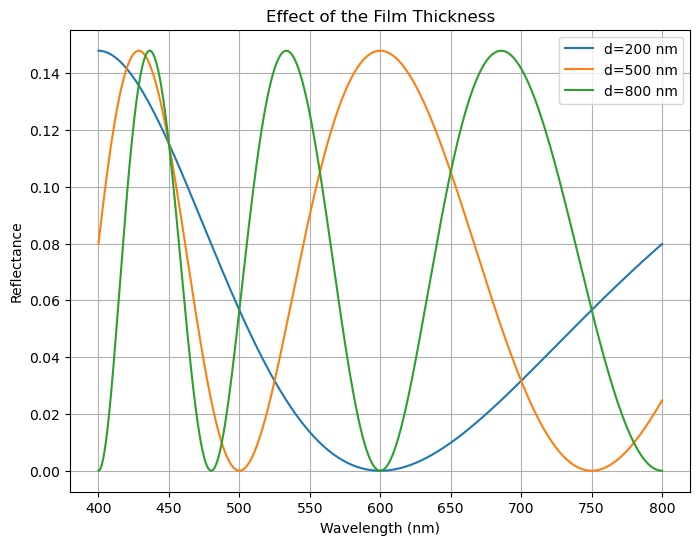

In [22]:
d_values=[200e-9, 500e-9, 800e-9]

plt.figure(figsize=(8,6))

for d in d_values:
    delta = (4 * np.pi * n2 * d) / lambda_ 
    r_total = (r12 + r23 * np.exp(1j * delta)) / (1 + r12 * r23 * np.exp(1j * delta))
    R = np.abs(r_total)**2
    plt.plot(lambda_ * 1e9, R, label= f"d={d*1e9:.0f} nm")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Effect of the Film Thickness")
plt.legend()
plt.grid()
plt.savefig(f"{folder_path}/Effect of the Film Thickness.png", dpi=300)
plt.show()

Increasing the thickness reduces the free spectral range, leading to more closely spaced resonances. This behaviour follows directly from the phase accumulation $ \delta\propto d$.

Para n2 =  1.2 -> Reflectividad = 0.0083, Finesse = 0.29
Approximate FSR(nm): 187.5
Para n2 =  1.5 -> Reflectividad = 0.0400, Finesse = 0.65
Approximate FSR(nm): 150.0
Para n2 =  2.0 -> Reflectividad = 0.1111, Finesse = 1.18
Approximate FSR(nm): 112.5


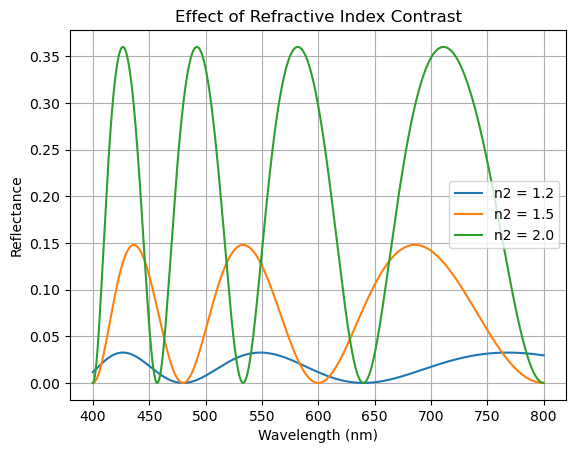

In [23]:
n2_values = [1.2, 1.5, 2.0]

for n2 in n2_values:
    r12 = (n1 - n2) / (n1 + n2)
    r23 = (n2 - n3) / (n2 + n3)

    delta = (4 * np.pi * n2 * d) / lambda_

    r_total = (r12 + r23 * np.exp(1j * delta)) / (1 + r12 * r23 * np.exp(1j * delta))

    R = np.abs(r_total)**2

    plt.plot(lambda_ * 1e9, R, label=f"n2 = {n2}")

    R_interface = np.abs(r12)**2
    F = (np.pi * np.sqrt(R_interface)) / (1-R_interface)

    print(f"Para n2 =  {n2} -> Reflectividad = {R_interface:.4f}, Finesse = {F:.2f}")

    lambda0 = 600e-9  # central wavelength
    FSR = lambda0**2 / (2 * n2 * d)

    print("Approximate FSR(nm):", FSR * 1e9)


plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Effect of Refractive Index Contrast")
plt.legend()
plt.grid()
plt.savefig(f"{folder_path}/ThinFilm_Effect of Refractive Index Contrast.png", dpi=300)
plt.show()

Higher refractive index contrast increases reflectivity at the interfaces, enhancing resonance visibility and cavity selectivity.

In [28]:
T = 1 - R    # Transmittance

print("Maximum deviation from energy conservation:", np.max(np.abs(R + T -1)))

Maximum deviation from energy conservation: 0.0


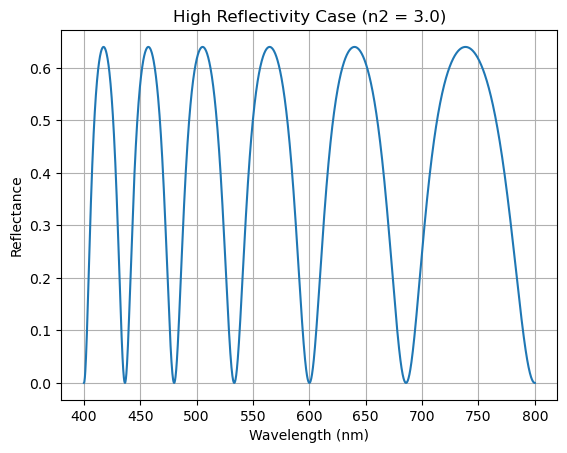

Finesse parameter (high reflectivity):: 1.7777777777777777


In [24]:
n2_high = 3.0

r12 = (n1 - n2_high) / (n1 + n2_high)
r23 = (n2_high - n3) / (n2_high + n3)

delta = (4 * np.pi * n2_high* d) / lambda_

r_total = (r12 + r23 * np.exp(1j * delta)) / (1 + r12 * r23 * np.exp(1j * delta))

R_high = np.abs(r_total)**2

plt.plot(lambda_ * 1e9, R_high)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("High Reflectivity Case (n2 = 3.0)")
plt.grid()
plt.savefig(f"{folder_path}/ThinFilm_HighReflectivity.png", dpi=300)
plt.show()

R_interface = r12**2
F = (4 * R_interface) / (1 - R_interface)**2
print("Finesse parameter (high reflectivity)::", F )

## Results and Discussion

The reflectance spectrum exhibits periodic resonance peaks arising from constructive interference inside the thin film.

The resonance condition $2n_2 d=m\lambda$ accurately predicts the peak positions. The separation between adjacent peaks, known as the free spectral range, is inversely proportional to the film thickness in agreement with the analytical approximation $\Delta\lambda = \dfrac{\lambda ^2}{2n_2 d}$.

Increasing the refractive index contrast enhances interface reflectivity, which increases the finesse of the cavity and produces sharper, more selective resonance peaks.

The numerical verification of the relation $(R + T =1)$ confirms energy conservation in lossless dielctric media and validates the correctness of the computational implementation.

In the high reflectivity limit, the thin film approaches the behavior of an ideal Fabry-Pérot resonator, demonstrating how Maxwell's boundary conditions and phase accumulation lead to highly selective optical filtering.

This study illustrates the deep connection between Maxwell's boundary conditions, wave interference and practical optical device desing.